## Exploratory Data Analysis


### The EDA Visualization Toolkit

- Histograms — distribution of a single continuous variable. Skewness, peaks, gaps, all visible at a glance.
- Box plots — spread and outliers compactly. Box = IQR, line = median, whiskers = non-outlier extremes, dots = flagged outliers. Great for comparing distributions across categories.
- Scatter plots — relationship between two continuous variables. The most direct way to see correlations, clusters, and nonlinear patterns.
- Pair plots — all pairwise scatter plots in a grid, histograms on the diagonal. Indispensable when you have a modest number of features and want to scan everything at once.
- Correlation heatmaps — color-coded correlation matrix. Faster to read than raw numbers; patterns jump out immediately.
-Bar charts by category — count or distribution broken out by a categorical variable. Quick way to spot imbalance.


In [109]:
# importing libararies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
%matplotlib inline

In [111]:
# Load in the processed data
final_motorcycles_df = pd.read_csv("../data/processed/final_motorcycles.csv")
print(final_motorcycles_df.shape)

(6901, 310)


C:\Users\hasan\AppData\Local\Temp\ipykernel_18440\3883263224.py:2: DtypeWarning: Columns (17,45,219) have mixed types. Specify dtype option on import or set low_memory=False.
  final_motorcycles_df = pd.read_csv("../data/processed/final_motorcycles.csv")


In [112]:
# Display first the number of accidnets from our raw data, and how many of those were accidnets by motorcycles.
vehicle = pd.read_csv("../data/raw/vehicle.csv", low_memory=False)
total_vehicles = vehicle.shape[0]
total_motorcycles = final_motorcycles_df.shape[0]

print("Total vehicles in fatal crashes:", total_vehicles)
print("Total motorcycles in fatal crashes:", total_motorcycles)
print("Percentage of vehicles that were motorcycles:", 
      round((total_motorcycles / total_vehicles) * 100, 2), "%")

Total vehicles in fatal crashes: 56011
Total motorcycles in fatal crashes: 6901
Percentage of vehicles that were motorcycles: 12.32 %


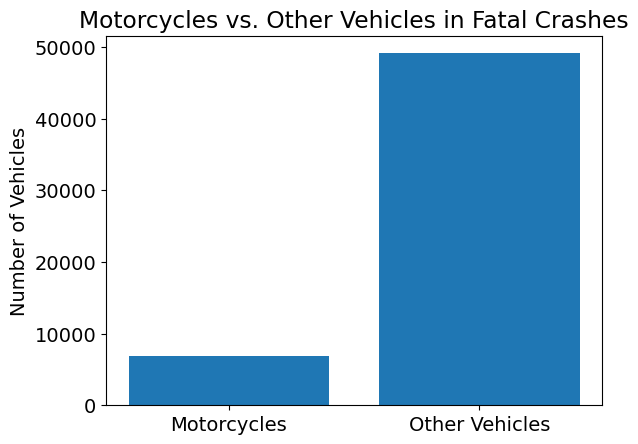

In [113]:
other_vehicles = total_vehicles - total_motorcycles

plt.bar(["Motorcycles", "Other Vehicles"], [total_motorcycles, other_vehicles])
plt.title("Motorcycles vs. Other Vehicles in Fatal Crashes")
plt.ylabel("Number of Vehicles")
plt.show()

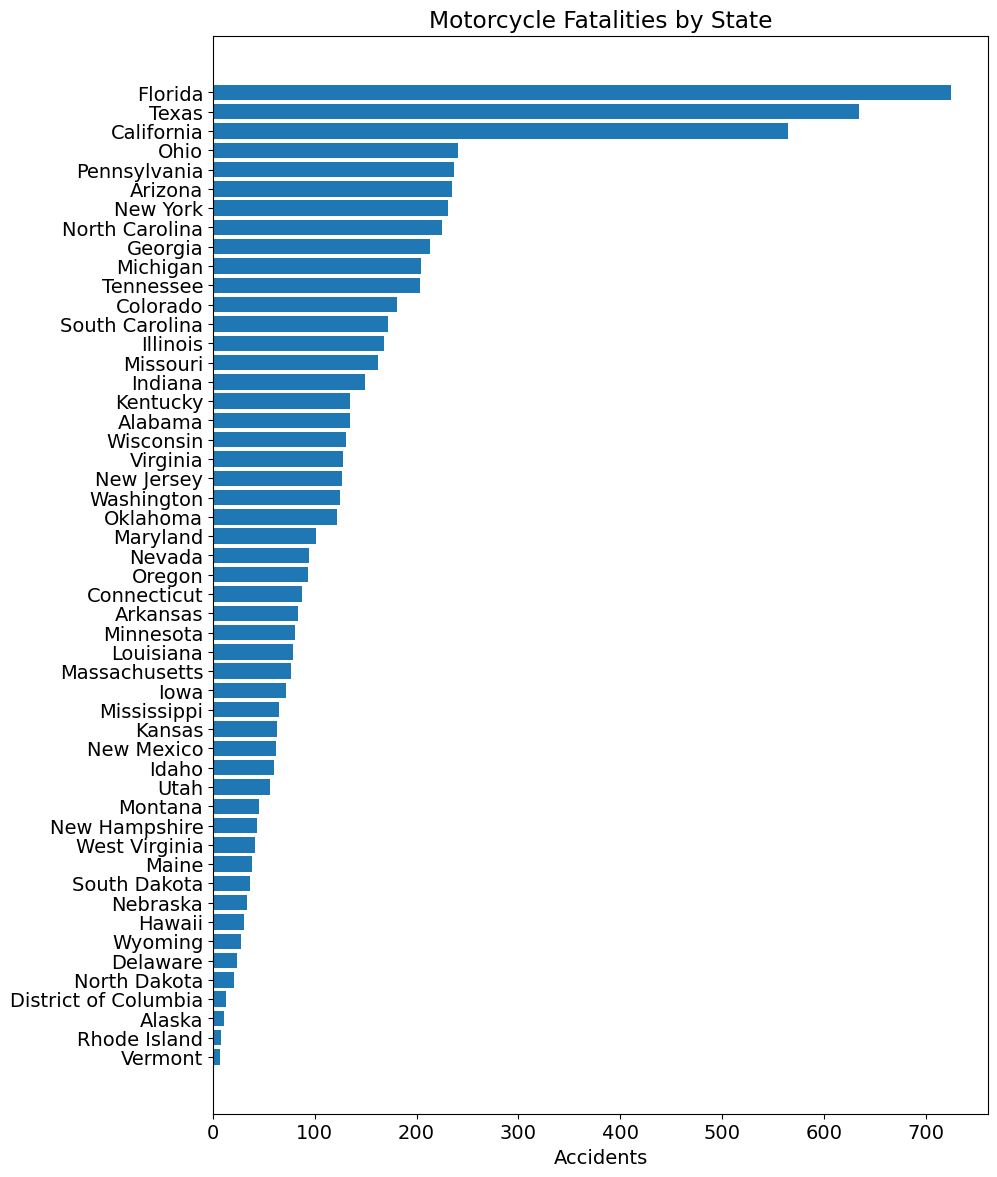

In [114]:
state_counts = final_motorcycles_df["STATENAME_x"].value_counts()

plt.figure(figsize=(10, 14))
plt.barh(state_counts.index, state_counts.values)
plt.title("Motorcycle Fatalities by State")
plt.xlabel("Accidents")
plt.gca().invert_yaxis()
plt.show()

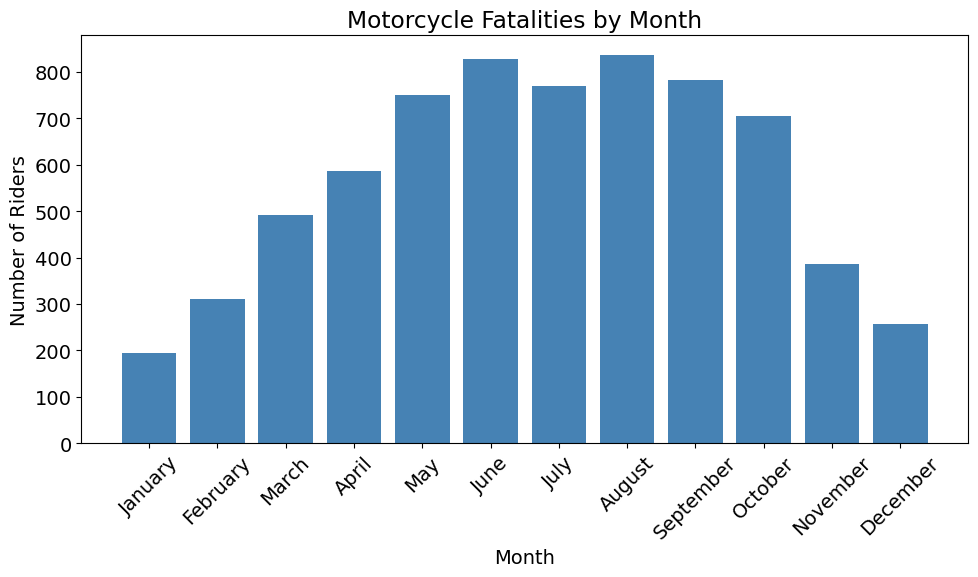

In [115]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

months = final_motorcycles_df["MONTHNAME_x"].value_counts().reindex(month_order)

plt.figure(figsize=(10, 6))
plt.bar(months.index, months.values, color="steelblue")
plt.title("Motorcycle Fatalities by Month")
plt.xlabel("Month")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

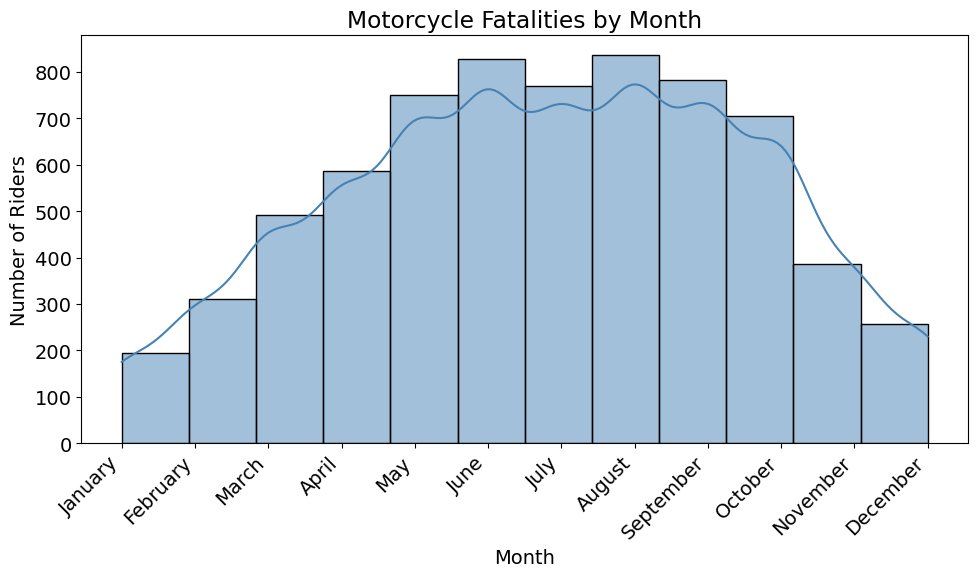

In [116]:
plt.figure(figsize=(10, 6))
sns.histplot(final_motorcycles_df["MONTH_x"], bins=12, kde=True, color="steelblue", edgecolor="black")
plt.title("Motorcycle Fatalities by Month")
plt.xlabel("Month")
plt.ylabel("Number of Riders")
plt.xticks(range(1, 13), month_order, rotation=45, ha="right")
plt.tight_layout()
plt.show()

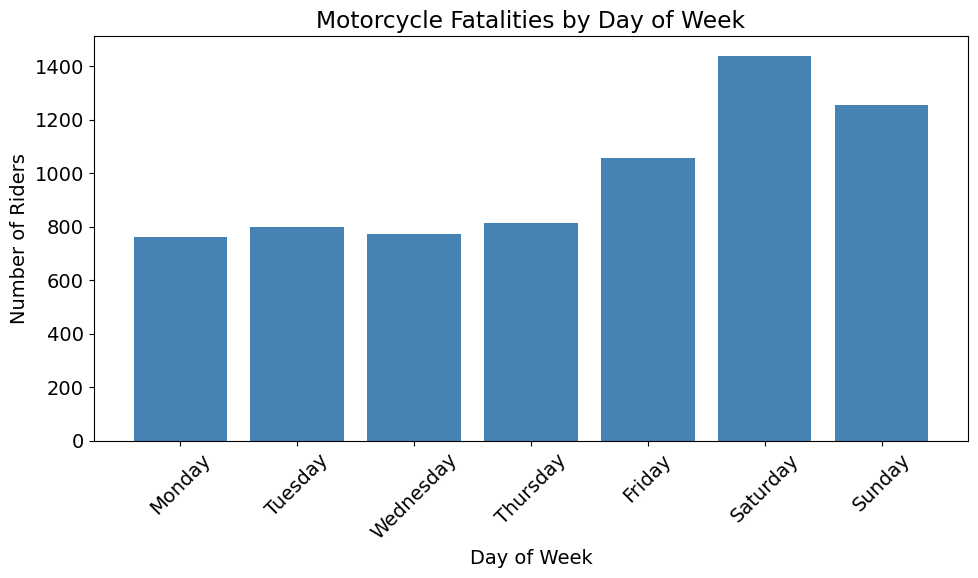

In [117]:
week_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
              "Friday", "Saturday", "Sunday"]

days = final_motorcycles_df["DAY_WEEKNAME"].value_counts().reindex(week_order)

plt.figure(figsize=(10, 6))
plt.bar(days.index, days.values, color="steelblue")
plt.title("Motorcycle Fatalities by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

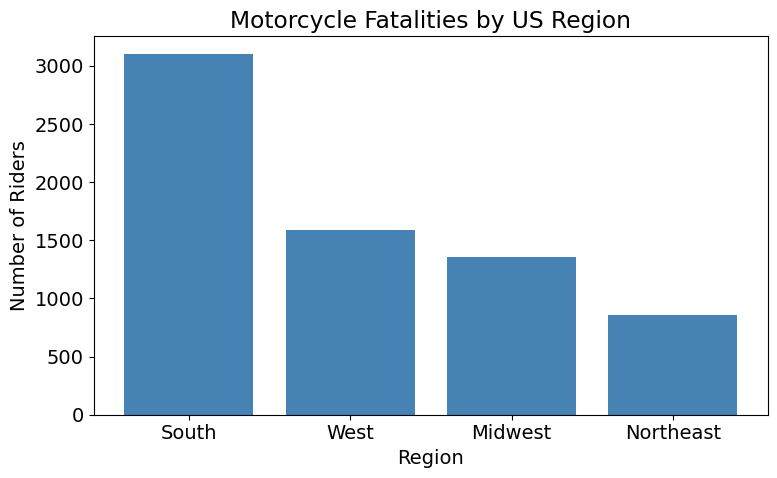

In [118]:
plt.figure(figsize=(8, 5))
region_counts = final_motorcycles_df["US_REGION"].value_counts()
plt.bar(region_counts.index, region_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities by US Region")
plt.xlabel("Region")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

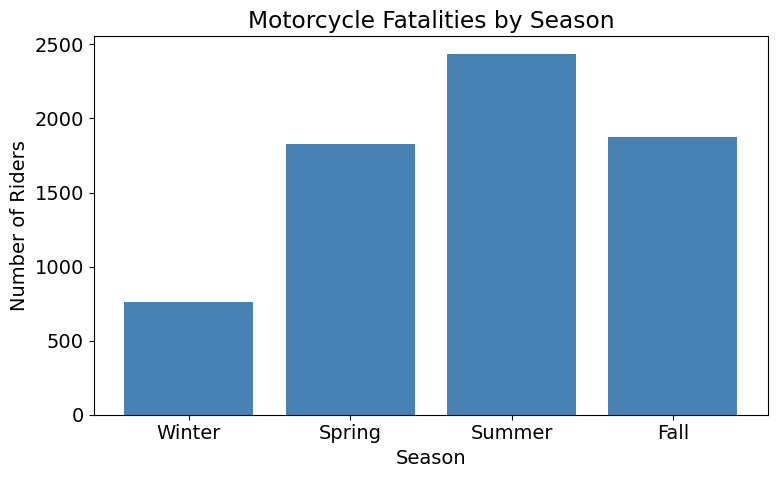

In [119]:
plt.figure(figsize=(8, 5))
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_counts = final_motorcycles_df["SEASON"].value_counts().reindex(season_order)
plt.bar(season_counts.index, season_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities by Season")
plt.xlabel("Season")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

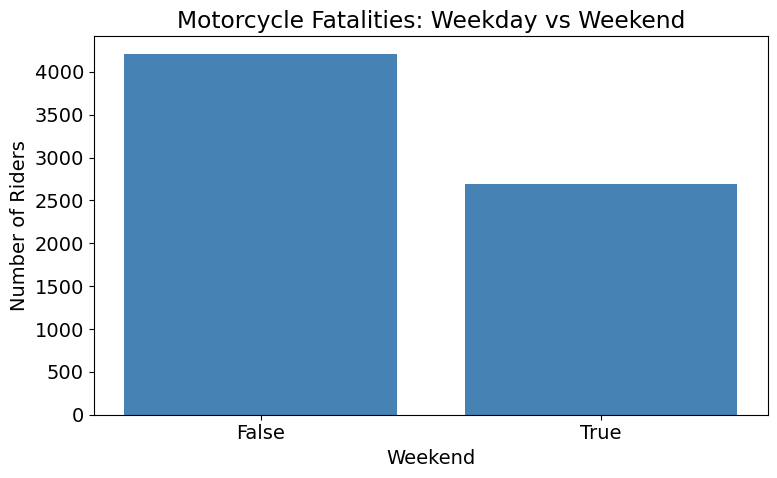

In [120]:
plt.figure(figsize=(8, 5))
weekend_counts = final_motorcycles_df["WEEKEND"].value_counts()
plt.bar(weekend_counts.index.astype(str), weekend_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities: Weekday vs Weekend")
plt.xlabel("Weekend")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

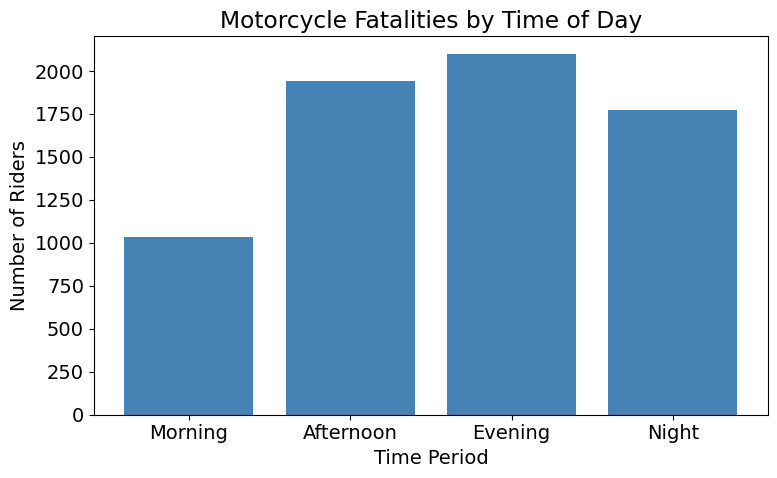

In [121]:
plt.figure(figsize=(8, 5))
time_order = ["Morning", "Afternoon", "Evening", "Night"]
time_counts = final_motorcycles_df["TIME_PERIOD"].value_counts().reindex(time_order)
plt.bar(time_counts.index, time_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

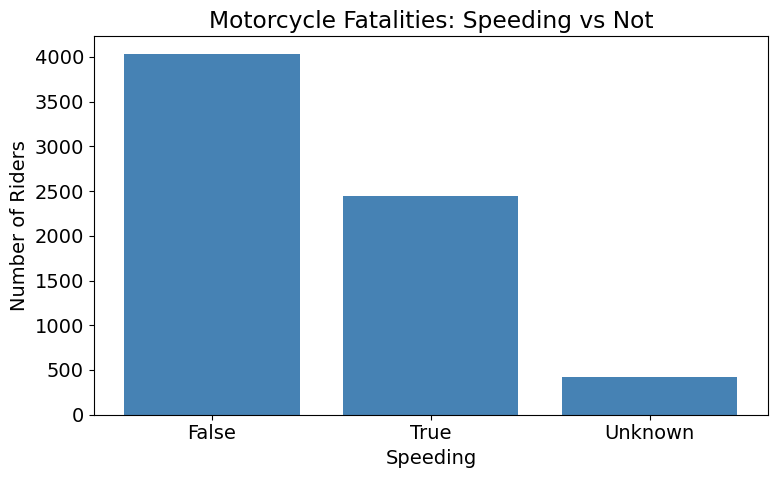

In [122]:
plt.figure(figsize=(8, 5))
speeding_counts = final_motorcycles_df["SPEEDING"].value_counts()
plt.bar(speeding_counts.index.astype(str), speeding_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities: Speeding vs Not")
plt.xlabel("Speeding")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

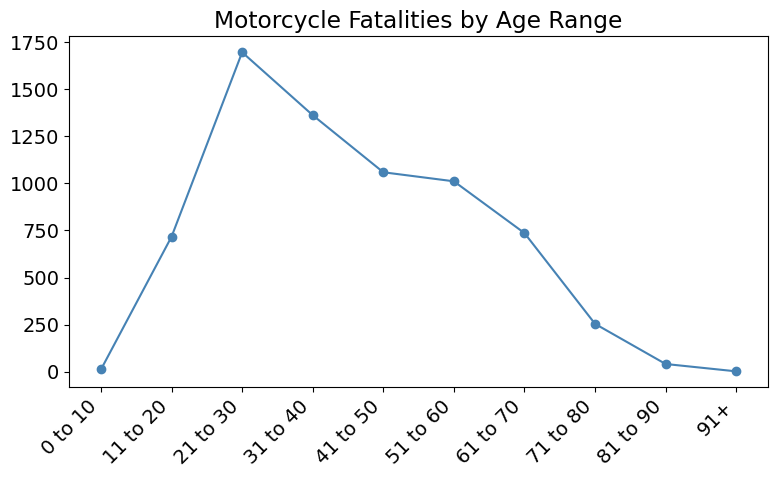

In [123]:
age_order = ["0 to 10", "11 to 20", "21 to 30", "31 to 40", "41 to 50",
             "51 to 60", "61 to 70", "71 to 80", "81 to 90", "91+"]
age_counts = final_motorcycles_df["AGE_RANGE"].value_counts().reindex(age_order)
plt.figure(figsize=(8, 5))
plt.plot(age_counts.index, age_counts.values, marker="o", color="steelblue")
plt.title("Motorcycle Fatalities by Age Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

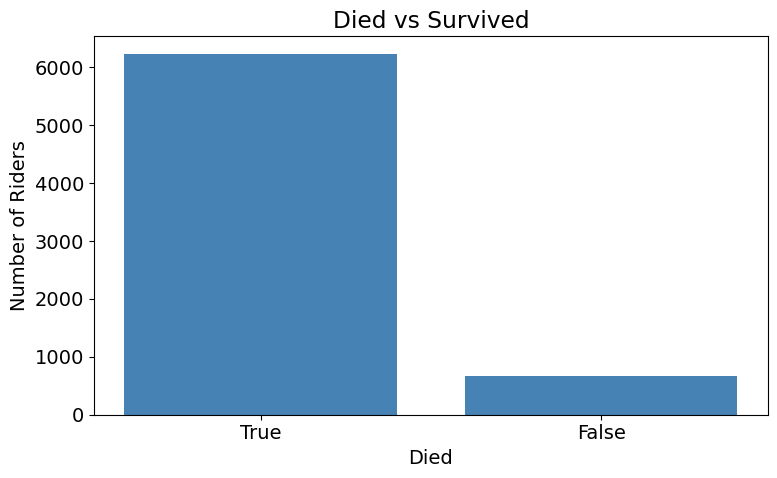

In [124]:
plt.figure(figsize=(8, 5))
died_counts = final_motorcycles_df["DIED"].value_counts()
plt.bar(died_counts.index.astype(str), died_counts.values, color="steelblue")
plt.title("Died vs Survived")
plt.xlabel("Died")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

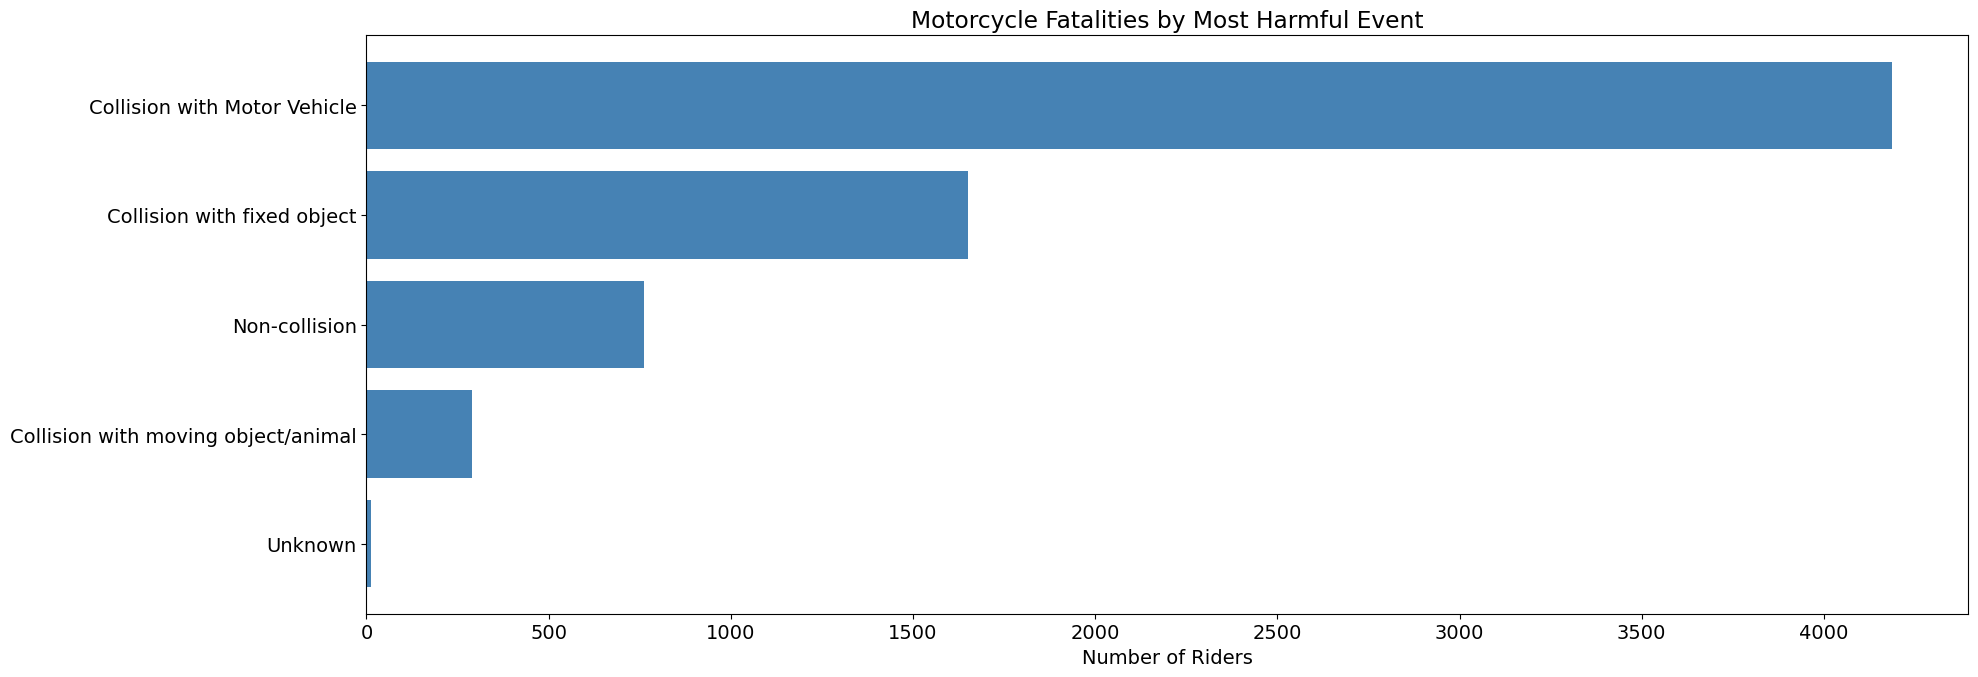

In [125]:
plt.figure(figsize=(20, 7))
harm_counts = final_motorcycles_df["MOST_HARMFUL_EVENT"].value_counts()
plt.barh(harm_counts.index, harm_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities by Most Harmful Event")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()  
plt.tight_layout()
plt.show()

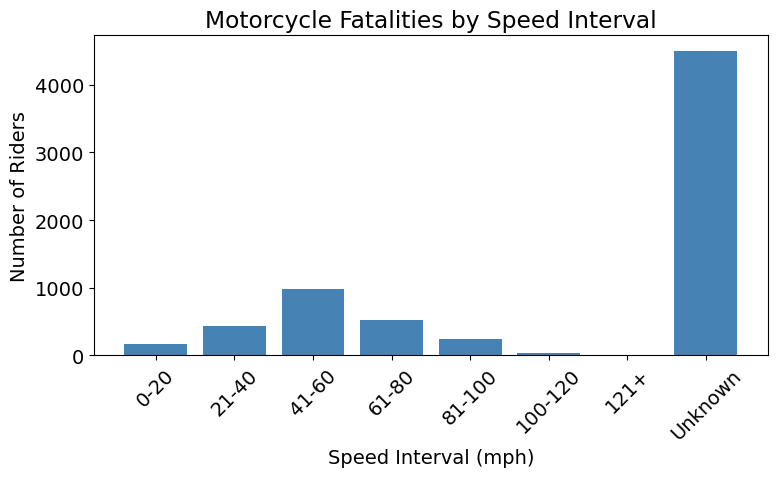

In [126]:
plt.figure(figsize=(8, 5))
speed_order = ["0-20", "21-40", "41-60", "61-80", "81-100", "100-120", "121+", "Unknown"]
speed_counts = final_motorcycles_df["SPEED_INTERVAL"].value_counts().reindex(speed_order)
plt.bar(speed_counts.index, speed_counts.values, color="steelblue")
plt.title("Motorcycle Fatalities by Speed Interval")
plt.xlabel("Speed Interval (mph)")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

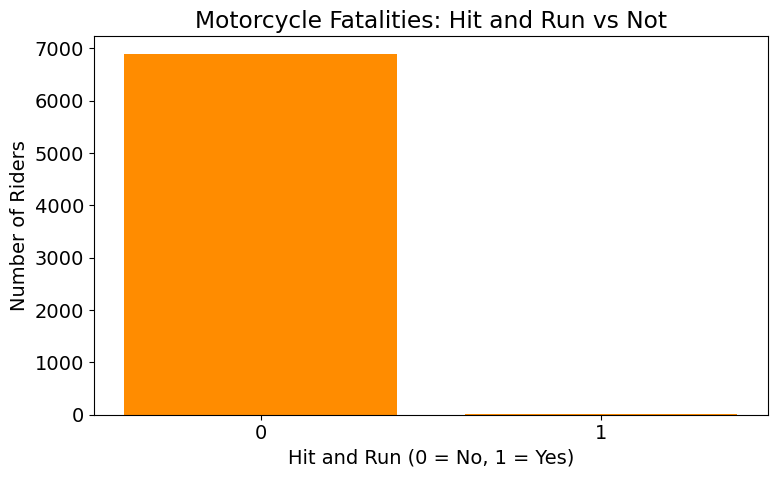

In [127]:
plt.figure(figsize=(8, 5))
hitrun_counts = final_motorcycles_df["HIT_RUN"].value_counts()
plt.bar(hitrun_counts.index.astype(str), hitrun_counts.values, color="darkorange")
plt.title("Motorcycle Fatalities: Hit and Run vs Not")
plt.xlabel("Hit and Run (0 = No, 1 = Yes)")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

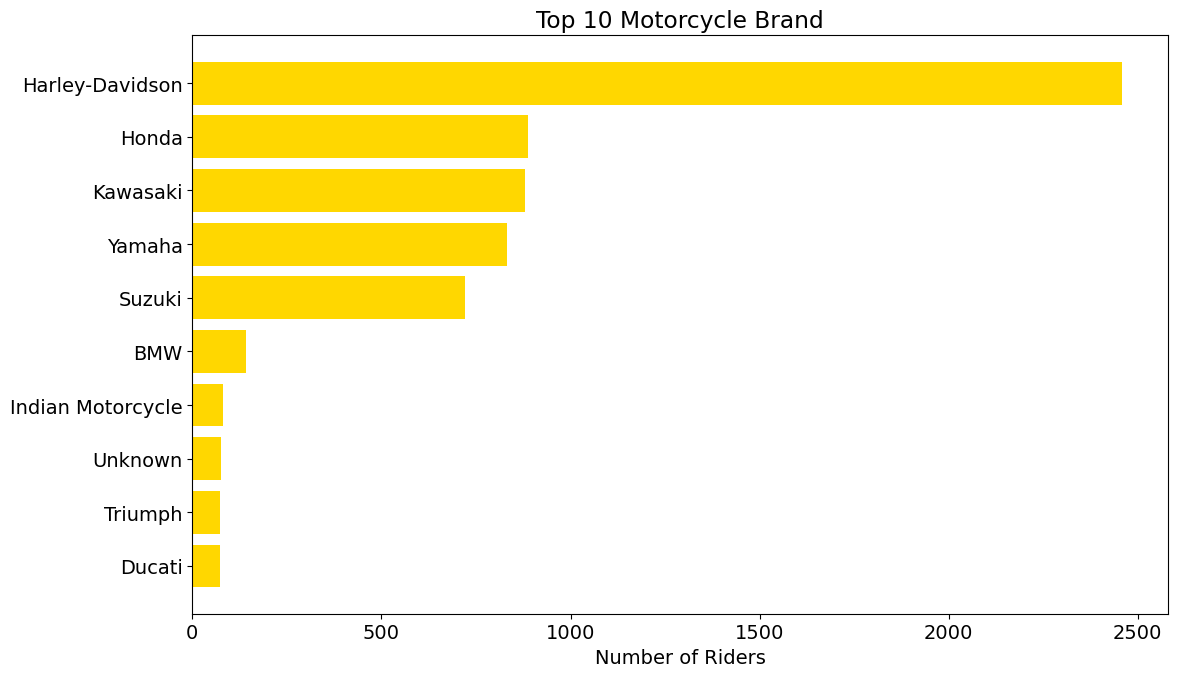

In [128]:
# Motorcycle brand name
plt.figure(figsize=(12, 7))
make_counts = final_motorcycles_df["VPICMAKENAME_x"].value_counts().head(10)
plt.barh(make_counts.index, make_counts.values, color="gold")
plt.title("Top 10 Motorcycle Brand")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

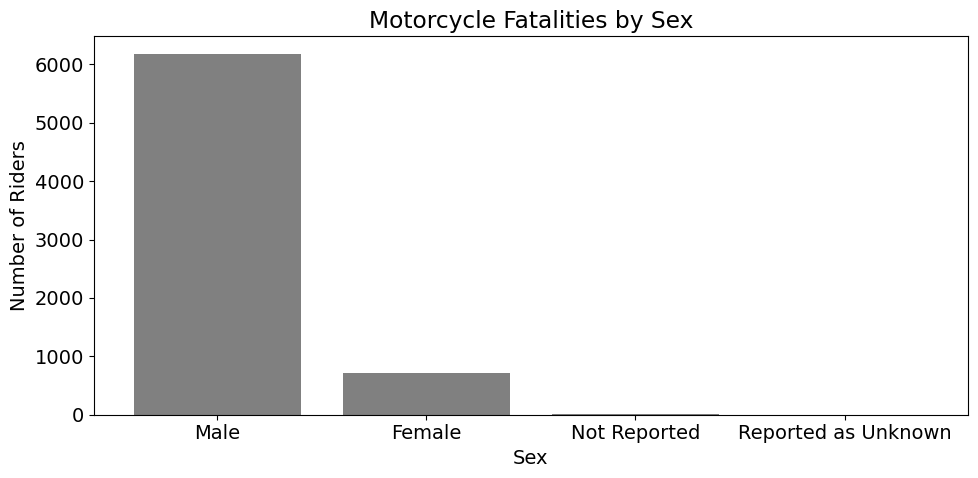

In [129]:
plt.figure(figsize=(10, 5))
sex_counts = final_motorcycles_df["SEXNAME"].value_counts()
plt.bar(sex_counts.index, sex_counts.values, color="gray")
plt.title("Motorcycle Fatalities by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

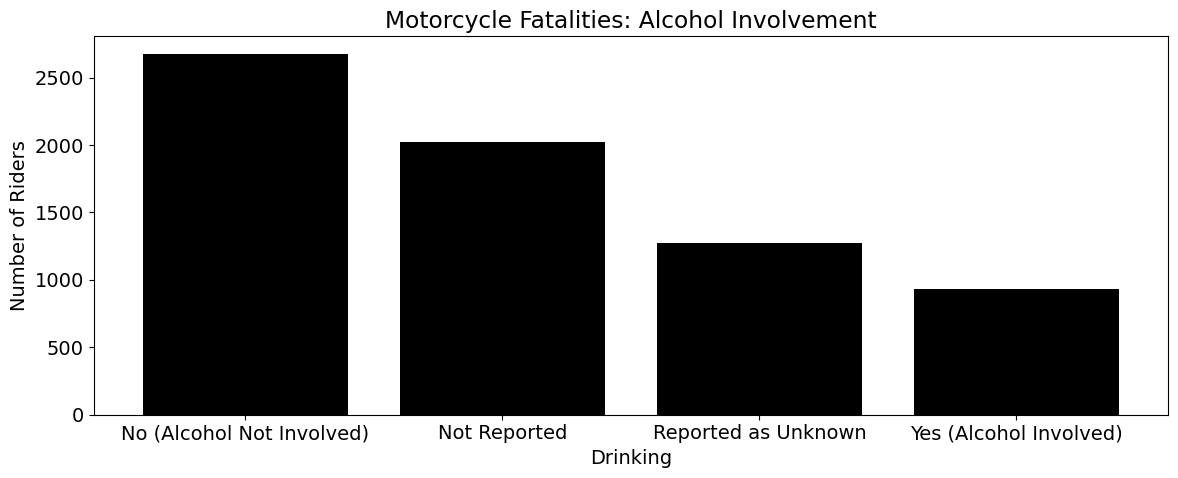

In [130]:
# was driver drinking?
plt.figure(figsize=(12, 5))
drinking_counts = final_motorcycles_df["DRINKINGNAME"].value_counts()
plt.bar(drinking_counts.index, drinking_counts.values, color="black")
plt.title("Motorcycle Fatalities: Alcohol Involvement")
plt.xlabel("Drinking")
plt.ylabel("Number of Riders")
plt.tight_layout()
plt.show()

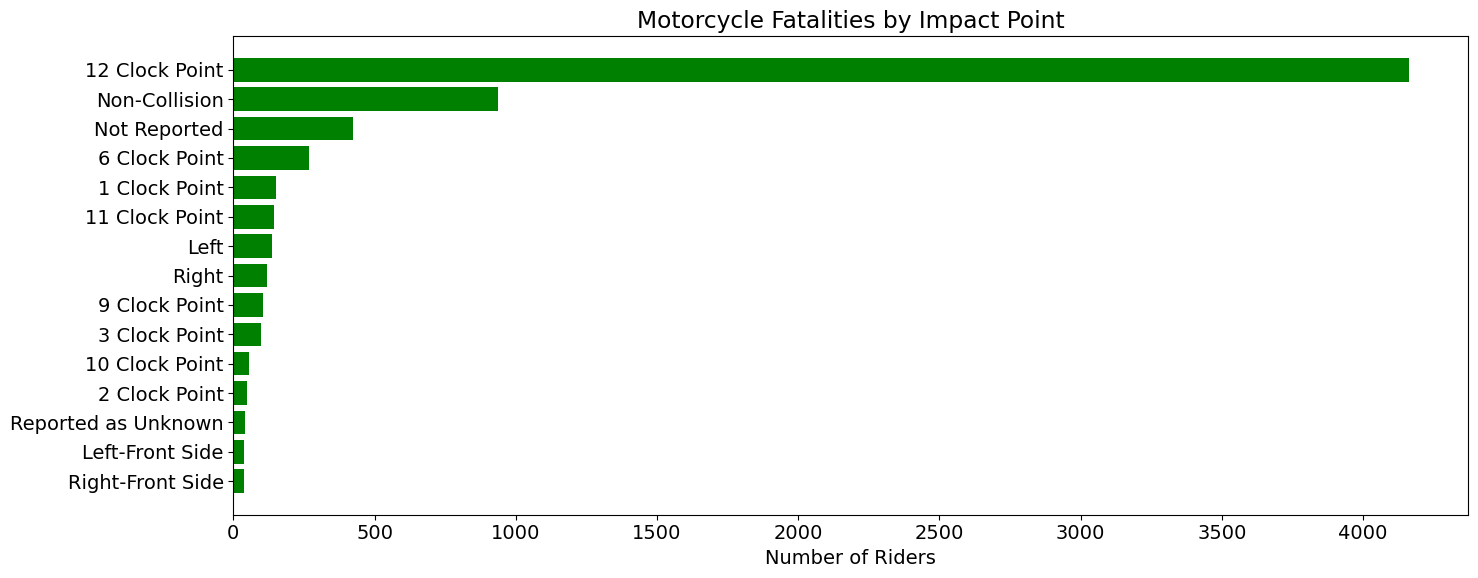

In [131]:
# impact point, where vechicle was impacted
plt.figure(figsize=(15, 6))
impact_counts = final_motorcycles_df["IMPACT1NAME_x"].value_counts().head(15)
plt.barh(impact_counts.index, impact_counts.values, color="green")
plt.title("Motorcycle Fatalities by Impact Point")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

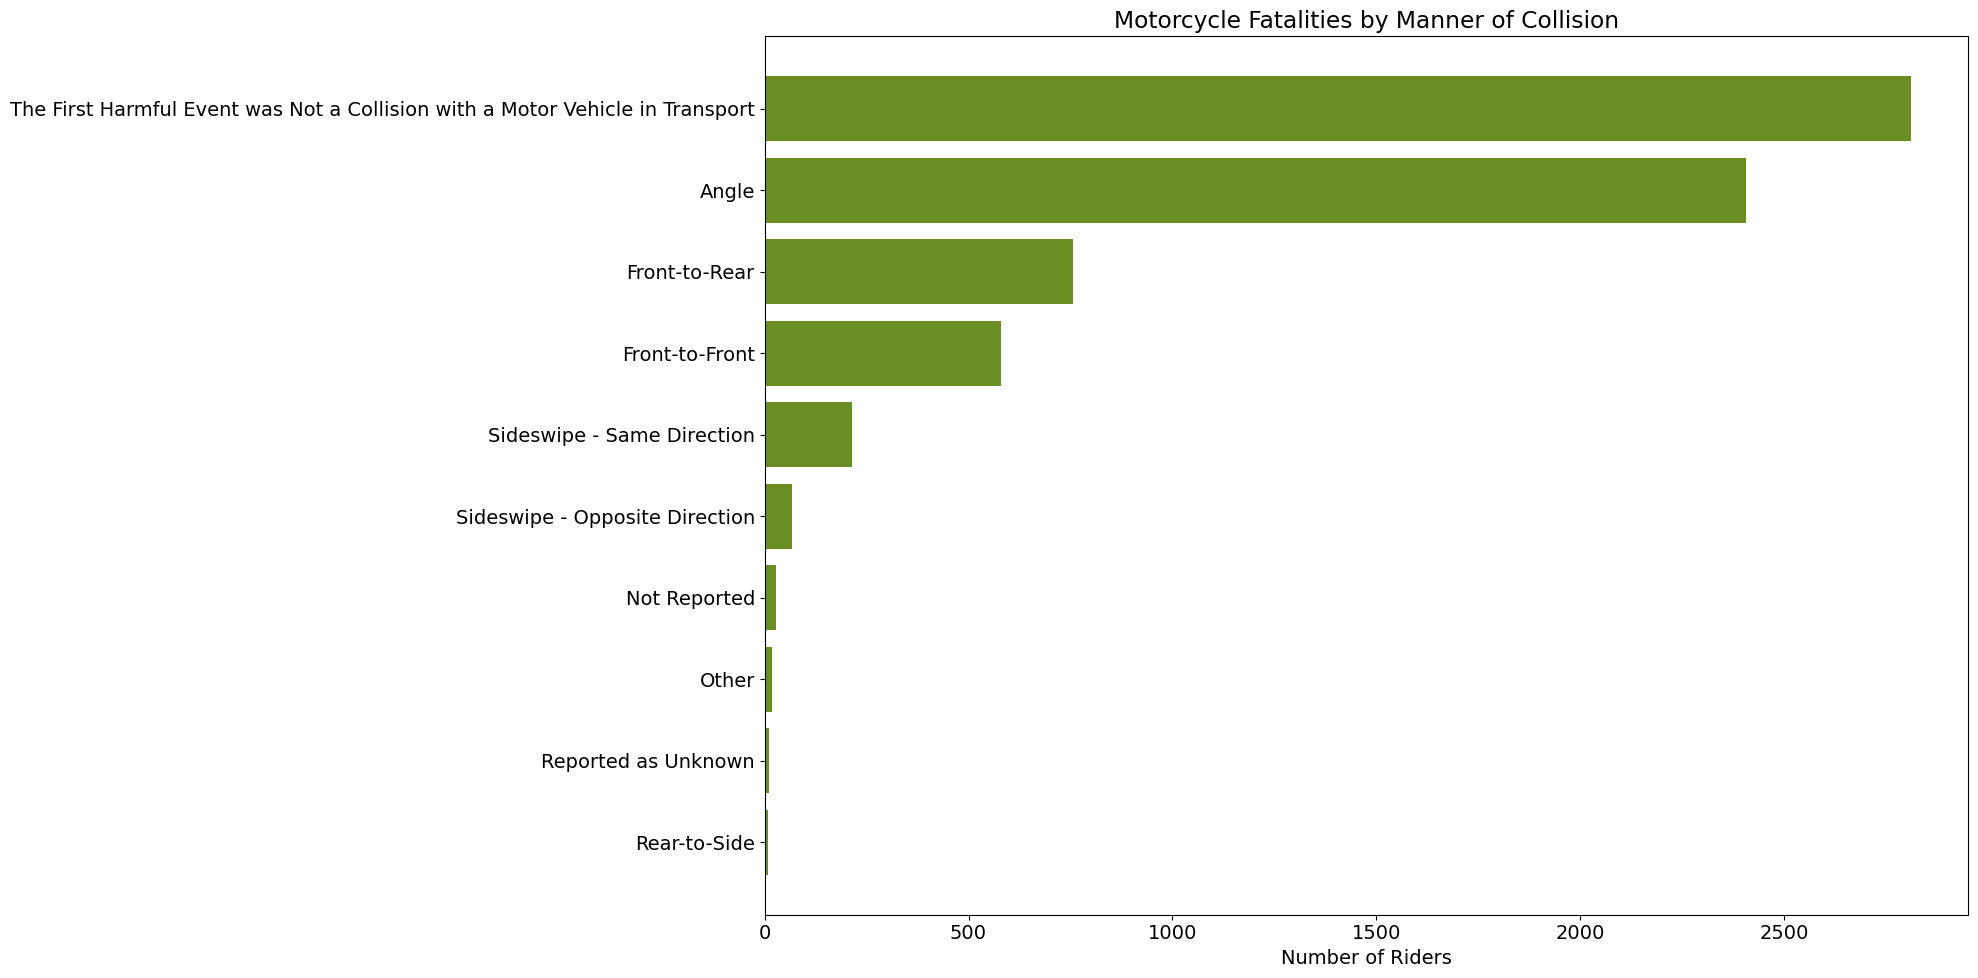

In [132]:
# orientation of the two vechiles on impact
plt.figure(figsize=(20, 10))
man_coll_counts = final_motorcycles_df["MAN_COLLNAME_x"].value_counts()
plt.barh(man_coll_counts.index, man_coll_counts.values, color="olivedrab")
plt.title("Motorcycle Fatalities by Manner of Collision")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

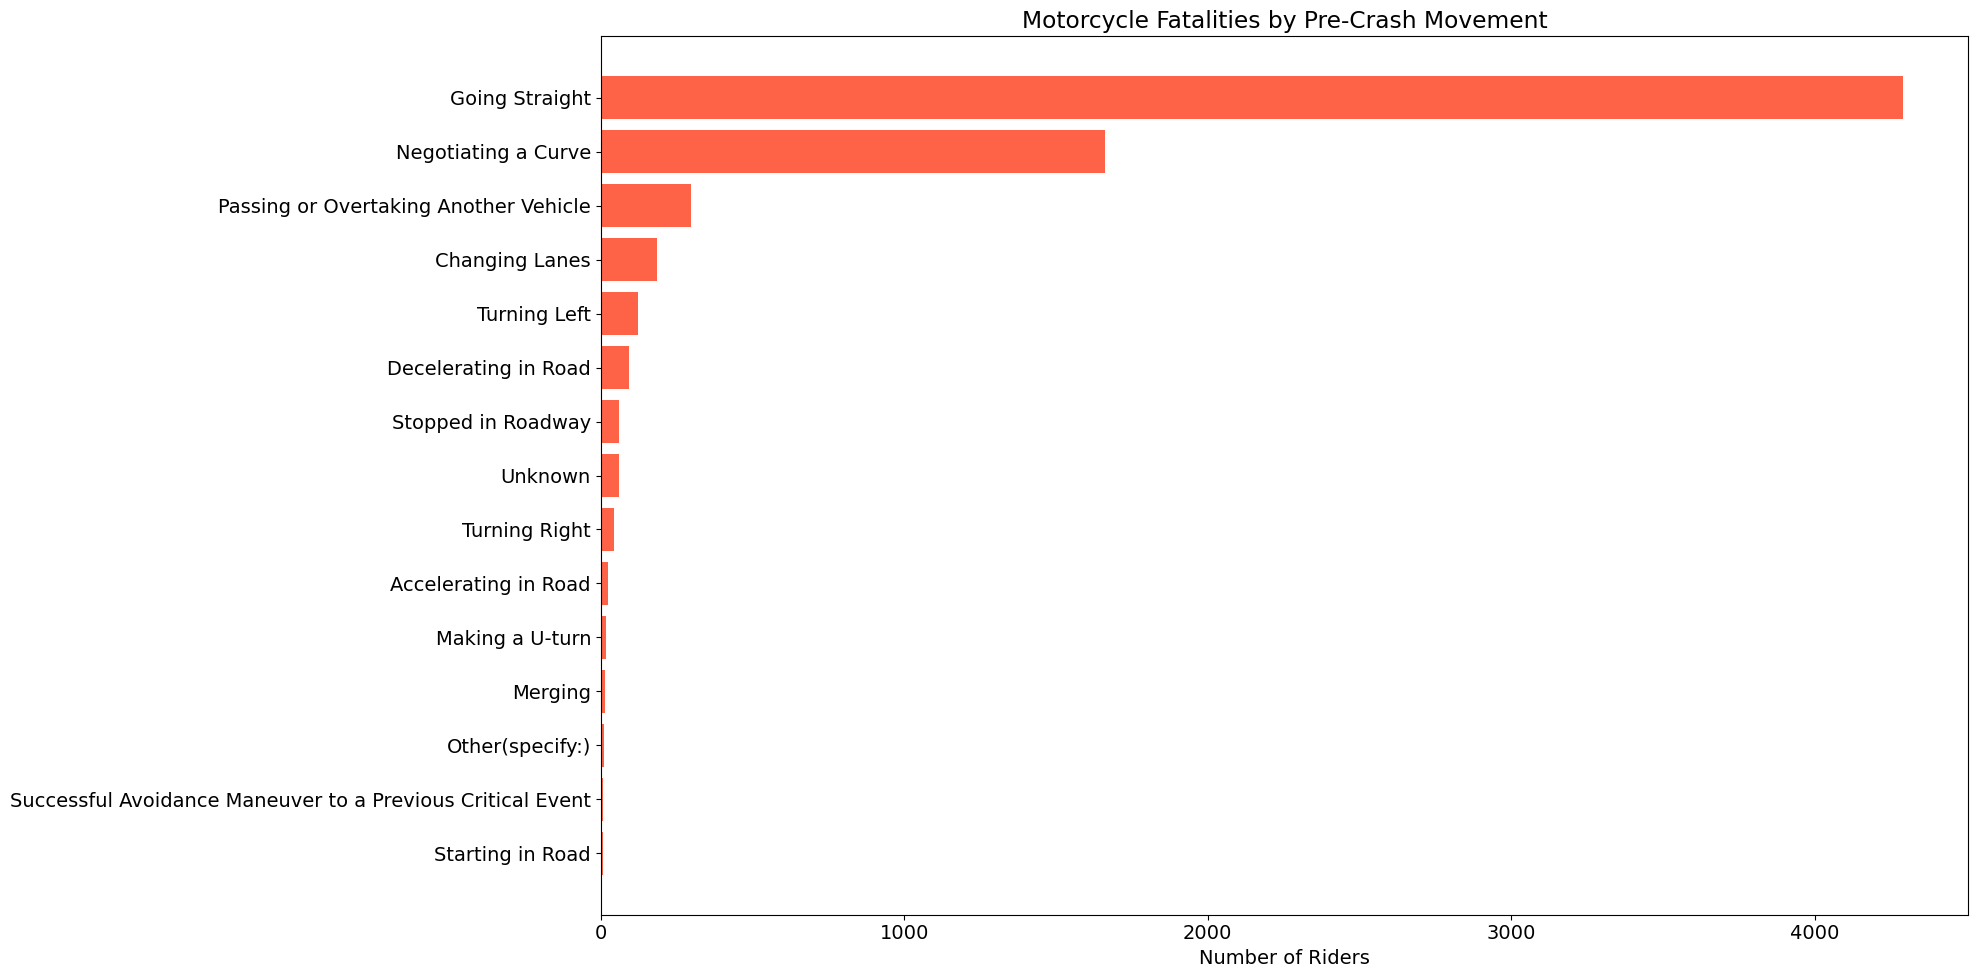

In [133]:
# what driver was doing prio to crash
plt.figure(figsize=(20, 10))
precrash_counts = final_motorcycles_df["P_CRASH1NAME"].value_counts().head(15)
plt.barh(precrash_counts.index, precrash_counts.values, color="tomato")
plt.title("Motorcycle Fatalities by Pre-Crash Movement")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

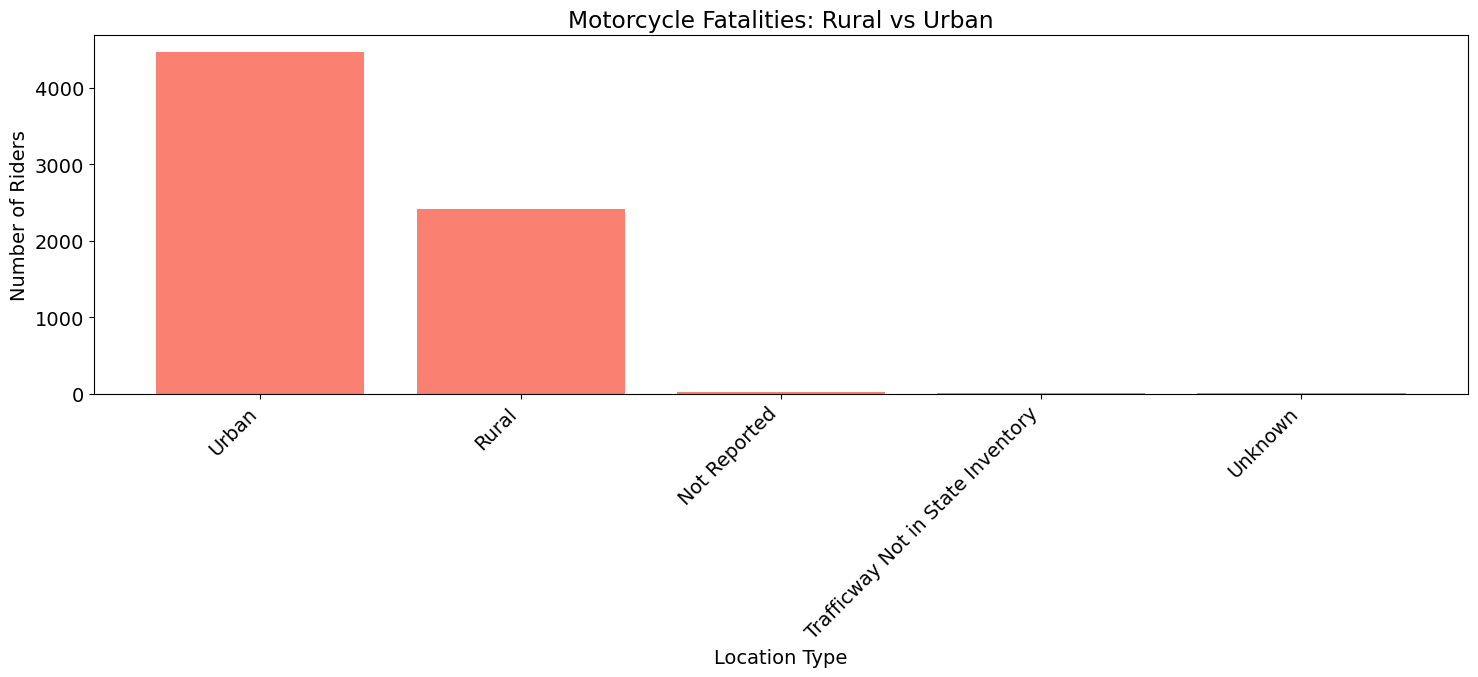

In [134]:
# was crash in rual or Urban or Trafficway(Private property or parking lot)
plt.figure(figsize=(15, 7))
rurb_counts = final_motorcycles_df["RUR_URBNAME_x"].value_counts()
plt.bar(rurb_counts.index, rurb_counts.values, color="salmon")
plt.title("Motorcycle Fatalities: Rural vs Urban")
plt.xlabel("Location Type")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

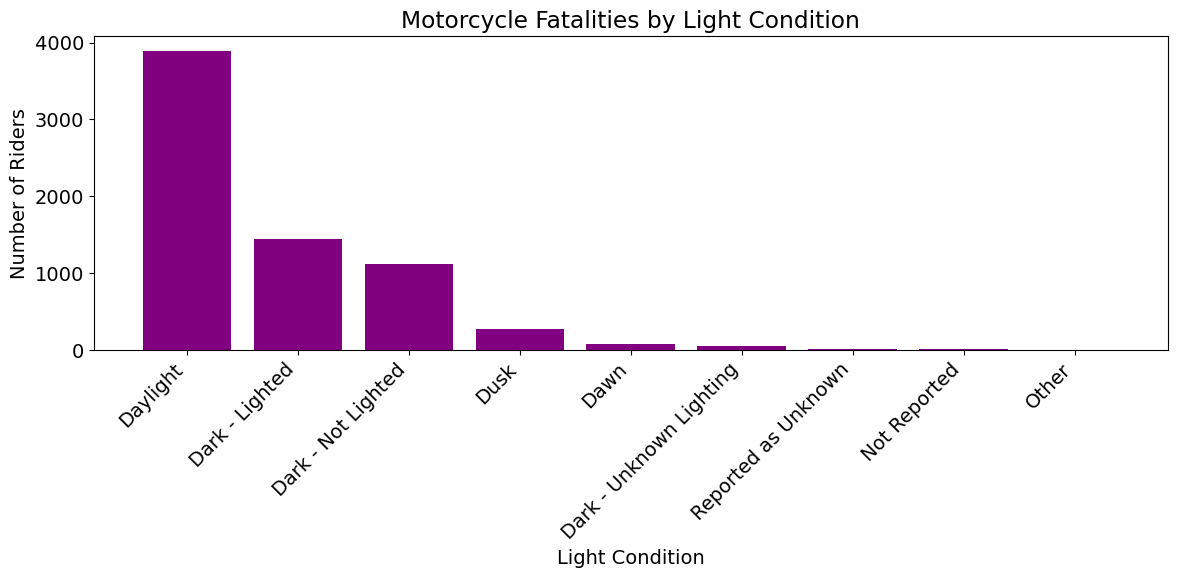

In [135]:
# light condition of when the crash occured 
plt.figure(figsize=(12, 6))
lgt_counts = final_motorcycles_df["LGT_CONDNAME"].value_counts()
plt.bar(lgt_counts.index, lgt_counts.values, color="purple")
plt.title("Motorcycle Fatalities by Light Condition")
plt.xlabel("Light Condition")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

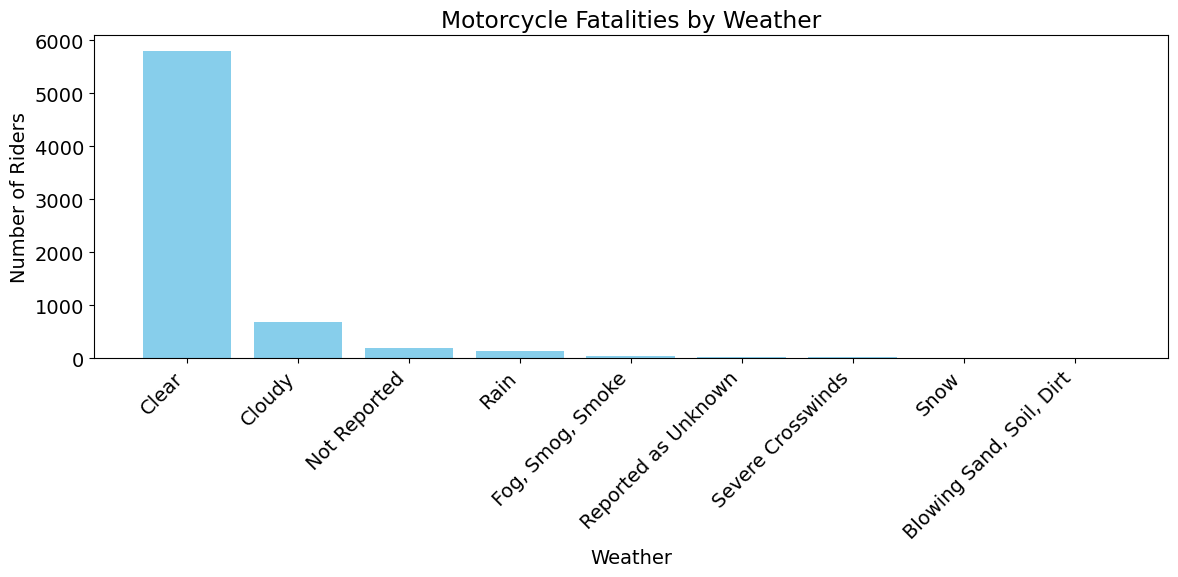

In [136]:
# weather when accident occured
plt.figure(figsize=(12, 6))
weather_counts = final_motorcycles_df["WEATHERNAME"].value_counts()
plt.bar(weather_counts.index, weather_counts.values, color="skyblue")
plt.title("Motorcycle Fatalities by Weather")
plt.xlabel("Weather")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

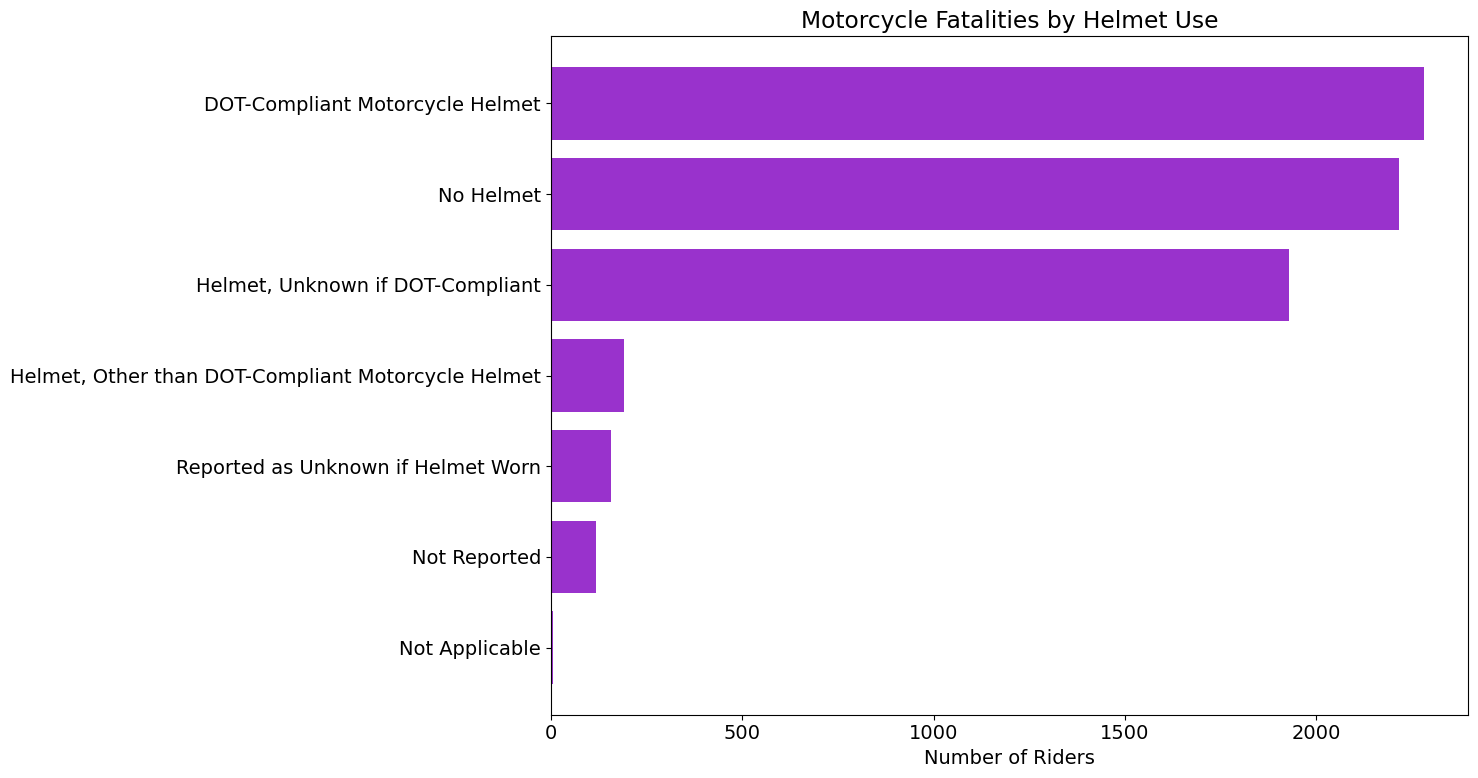

In [137]:
# wearing a helmet or not
plt.figure(figsize=(15, 8))
helm_counts = final_motorcycles_df["HELM_USENAME"].value_counts()
plt.barh(helm_counts.index, helm_counts.values, color="darkorchid")
plt.title("Motorcycle Fatalities by Helmet Use")
plt.xlabel("Number of Riders")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

C:\Users\hasan\AppData\Local\Temp\ipykernel_18440\1684021931.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


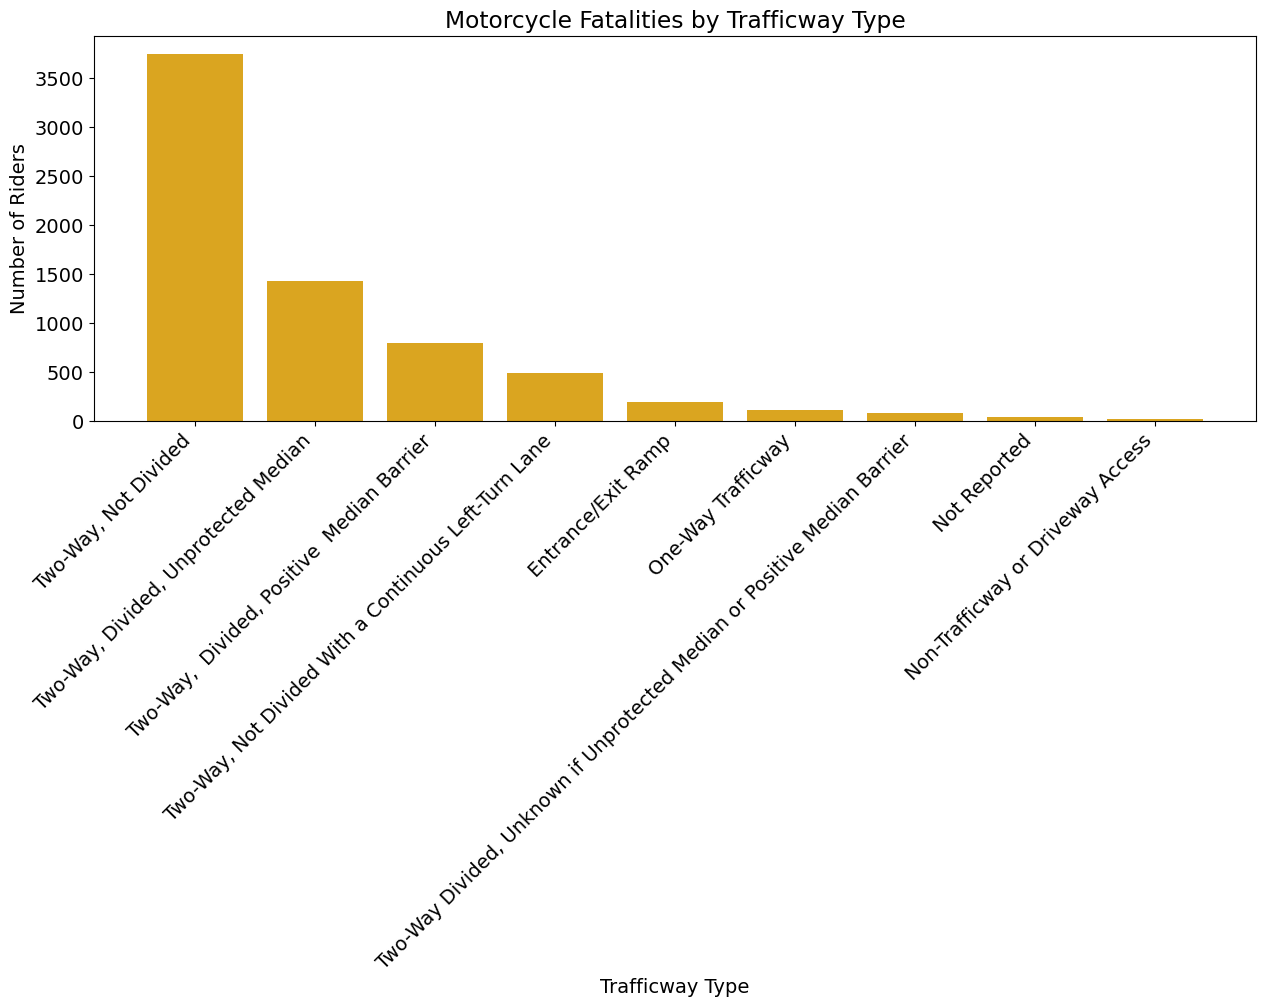

In [138]:
# tells you what kind of road it was one, a two way, that was divided or not etc
plt.figure(figsize=(15, 5))
vtraf_counts = final_motorcycles_df["VTRAFWAYNAME"].value_counts()
plt.bar(vtraf_counts.index, vtraf_counts.values, color="goldenrod")
plt.title("Motorcycle Fatalities by Trafficway Type")
plt.xlabel("Trafficway Type")
plt.ylabel("Number of Riders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()